# Waste Classification using CNN — Model Training and Evaluation
**Dataset:** Garbage Classification (12 classes) — Mostafa Abla, Kaggle
**Notebook author:** *Suyog Chhetri*
**TECH 405 — continuation of the Week 2 EDA notebook**

This notebook builds on the Week 2 exploratory data analysis. It loads the same cleaned data and
train/validation/test split, implements a convolutional neural network from scratch, trains several
hyperparameter configurations and compares them, trains a final model with the best configuration found,
and evaluates it with a confusion matrix, precision, recall, and F1-score. Every code cell's output is
preserved when the notebook is run, so the executed notebook itself supplies the screenshots needed for
the written report.


In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import hashlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import tensorflow as tf

if tf.__version__.split(".")[:2] != ["2", "10"]:
    raise RuntimeError("Select the Python (TF GPU) kernel with TensorFlow 2.10.1, then restart the kernel.")

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError("No GPU detected. Check the NVIDIA driver, CUDA 11.2, cuDNN 8.1, and the selected tf-gpu environment.")

# Configure GPU memory before creating tensors or models.
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_fscore_support, accuracy_score,
)

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
tf.keras.utils.set_random_seed(RNG_SEED)

plt.rcParams["figure.facecolor"] = "white"
print("TensorFlow version:", tf.__version__)
print("GPUs available:", gpus)
print("Keras will automatically use the GPU for supported operations.")


TensorFlow version: 2.10.1
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras will automatically use the GPU for supported operations.


## 2. Reload the cleaned data and the train/validation/test split

This repeats the loading, de-duplication, and stratified 70/15/15 split from the Week 2 EDA notebook
(`suyog_eda.ipynb`), using the same random seed so the same images end up in the same split here.


In [10]:
project_root = Path(r"C:\Users\LEGION\Documents\BScIT\TECH 405")
DATA_DIR = Path.cwd() / "garbage_classification"

if not DATA_DIR.exists():
    DATA_DIR = project_root / "garbage_classification"

if not DATA_DIR.exists():
    for base in [Path.cwd(), project_root, Path.cwd().parent]:
        candidate = base / "garbage_classification"
        if candidate.exists():
            DATA_DIR = candidate
            break

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Could not find the garbage_classification dataset. "
        "Make sure the folder is in the project root or update the path."
    )

candidates = [p for p in DATA_DIR.rglob("*") if p.is_dir() and
              len([f for f in p.iterdir() if f.is_file()]) > 0 and
              len(list(p.parent.glob("*"))) >= 6]
if not (DATA_DIR / "cardboard").exists() and candidates:
    DATA_DIR = candidates[0].parent

print("Using DATA_DIR:", DATA_DIR.resolve())

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
records = []
for class_dir in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    for f in class_dir.iterdir():
        if f.suffix.lower() in IMG_EXTS:
            records.append({"filepath": str(f), "label": class_dir.name})

df = pd.DataFrame(records)
print("Raw dataset shape:", df.shape)


Using DATA_DIR: C:\Users\LEGION\Documents\BScIT\TECH 405\garbage_classification
Raw dataset shape: (15515, 2)


In [11]:
# Drop corrupt/unreadable files and exact duplicates, exactly as in the Week 2 EDA notebook
corrupt_files = []
for fp in df["filepath"]:
    try:
        with Image.open(fp) as im:
            im.verify()
    except (UnidentifiedImageError, OSError, ValueError):
        corrupt_files.append(fp)

def md5_of_file(path, block_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(block_size), b""):
            h.update(chunk)
    return h.hexdigest()

hashes = defaultdict(list)
for fp in df["filepath"]:
    hashes[md5_of_file(fp)].append(fp)

drop_as_duplicate = set()
for paths in hashes.values():
    drop_as_duplicate.update(paths[1:])

df_clean = df[~df["filepath"].isin(corrupt_files) & ~df["filepath"].isin(drop_as_duplicate)].reset_index(drop=True)
print(f"Rows before cleaning: {len(df)}  |  Rows after cleaning: {len(df_clean)}")

classes = sorted(df_clean["label"].unique())
num_classes = len(classes)
label_to_index = {c: i for i, c in enumerate(classes)}
df_clean["label_idx"] = df_clean["label"].map(label_to_index)
print(f"Classes ({num_classes}): {classes}")


Rows before cleaning: 15515  |  Rows after cleaning: 15496
Classes (12): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [12]:
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean["label"], random_state=RNG_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RNG_SEED
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")


Train: 10847  Val: 2324  Test: 2325


## 3. Build the tf.data input pipelines

Images are decoded, resized to 224x224, and scaled to [0, 1], matching the target resolution decided in
the Week 2 EDA. Training images additionally pass through a small augmentation block (random flip,
rotation, zoom, and contrast) so the model cannot rely on the background style shortcut identified as a
key EDA finding. Class weights are computed from the training split to counter the class imbalance also
identified in the EDA, and are passed into every training run below.


In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

def make_dataset(dataframe, training, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].values
    labels = dataframe["label_idx"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=RNG_SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_df["label_idx"].values,
)
class_weight = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights:")
for c, i in label_to_index.items():
    print(f"  {c:12s} -> {class_weight[i]:.2f}")


Class weights:
  battery      -> 1.37
  biological   -> 1.31
  brown-glass  -> 2.13
  cardboard    -> 1.45
  clothes      -> 0.24
  green-glass  -> 2.10
  metal        -> 1.68
  paper        -> 1.23
  plastic      -> 1.49
  shoes        -> 0.65
  trash        -> 1.85
  white-glass  -> 1.67


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0009977].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.017766863..1.0092771].


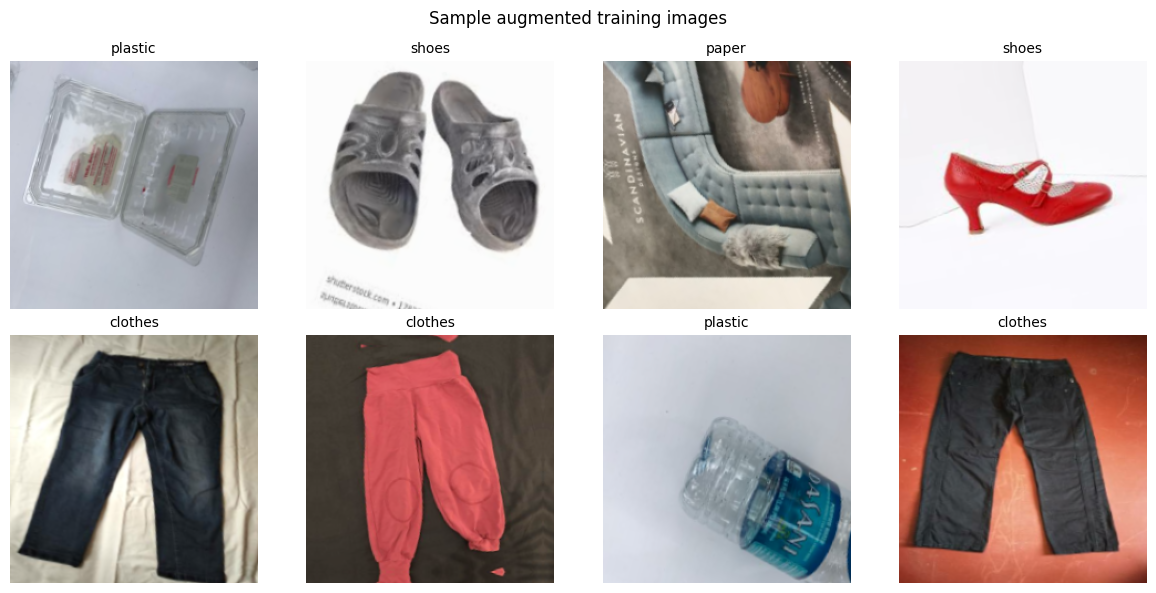

In [14]:
# Visual check: one augmented batch
sample_images, sample_labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.flatten(), sample_images[:8], sample_labels[:8]):
    ax.imshow(img.numpy())
    ax.set_title(classes[lbl.numpy()], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample augmented training images")
plt.tight_layout()
plt.show()


## 4. CNN architecture

A CNN is implemented from scratch: four convolution + max-pooling blocks with an increasing number of
filters, followed by global average pooling and a dense classification head with dropout. Learning rate,
dropout rate, and batch size are exposed as parameters so they can be varied in the hyperparameter
experiments below.


In [15]:
def build_cnn(learning_rate=1e-3, dropout_rate=0.3, dense_units=128, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

build_cnn().summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 28, 28, 128)      0

## 5. Hyperparameter experiments

Three configurations are trained for a small, equal number of epochs so their validation curves can be
compared directly: a baseline learning rate of 1e-3, a ten-times-smaller learning rate of 1e-4, and a
higher-dropout variant trained with a smaller batch size. The configuration with the best validation
accuracy is then trained for longer in Section 6.


In [16]:
HP_SEARCH_EPOCHS = 6

hyperparam_configs = {
    "A_baseline_lr1e-3":     {"learning_rate": 1e-3, "dropout_rate": 0.3, "batch_size": 32},
    "B_lower_lr1e-4":        {"learning_rate": 1e-4, "dropout_rate": 0.3, "batch_size": 32},
    "C_higher_dropout_bs16": {"learning_rate": 1e-3, "dropout_rate": 0.5, "batch_size": 16},
}

hp_histories = {}
hp_results = []

for name, cfg in hyperparam_configs.items():
    print(f"\n=== Training configuration: {name} -> {cfg} ===")
    tf.keras.utils.set_random_seed(RNG_SEED)
    cfg_train_ds = make_dataset(train_df, training=True, batch_size=cfg["batch_size"])
    cfg_val_ds = make_dataset(val_df, training=False, batch_size=cfg["batch_size"])
    model = build_cnn(learning_rate=cfg["learning_rate"], dropout_rate=cfg["dropout_rate"])
    history = model.fit(
        cfg_train_ds,
        validation_data=cfg_val_ds,
        epochs=HP_SEARCH_EPOCHS,
        class_weight=class_weight,
        shuffle=False,  # the tf.data pipeline already shuffles the training set
        verbose=2,
    )
    hp_histories[name] = history.history
    final_val_acc = history.history["val_accuracy"][-1]
    final_val_loss = history.history["val_loss"][-1]
    hp_results.append({"config": name, **cfg, "final_val_accuracy": final_val_acc, "final_val_loss": final_val_loss})

hp_results_df = pd.DataFrame(hp_results).sort_values("final_val_accuracy", ascending=False).reset_index(drop=True)
hp_results_df



=== Training configuration: A_baseline_lr1e-3 -> {'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} ===
Epoch 1/6
339/339 - 698s - loss: 2.4999 - accuracy: 0.1037 - val_loss: 2.4887 - val_accuracy: 0.0564 - 698s/epoch - 2s/step
Epoch 2/6
339/339 - 20s - loss: 2.4853 - accuracy: 0.0762 - val_loss: 2.4854 - val_accuracy: 0.0676 - 20s/epoch - 60ms/step
Epoch 3/6
339/339 - 20s - loss: 2.4866 - accuracy: 0.0504 - val_loss: 2.4864 - val_accuracy: 0.0676 - 20s/epoch - 58ms/step
Epoch 4/6
339/339 - 19s - loss: 2.4853 - accuracy: 0.0577 - val_loss: 2.4845 - val_accuracy: 0.0452 - 19s/epoch - 57ms/step
Epoch 5/6
339/339 - 19s - loss: 2.4855 - accuracy: 0.0626 - val_loss: 2.4857 - val_accuracy: 0.0559 - 19s/epoch - 57ms/step
Epoch 6/6
339/339 - 20s - loss: 2.4856 - accuracy: 0.0691 - val_loss: 2.4868 - val_accuracy: 0.0396 - 20s/epoch - 59ms/step

=== Training configuration: B_lower_lr1e-4 -> {'learning_rate': 0.0001, 'dropout_rate': 0.3, 'batch_size': 32} ===
Epoch 1/6
339/339 - 22

,config,learning_rate,dropout_rate,batch_size,final_val_accuracy,final_val_loss
0,C_higher_dropout_bs16,0.0010,0.5,16,0.570138,1.309433
1,B_lower_lr1e-4,0.0001,0.3,32,0.056799,2.485276
2,A_baseline_lr1e-3,0.0010,0.3,32,0.039587,2.486812


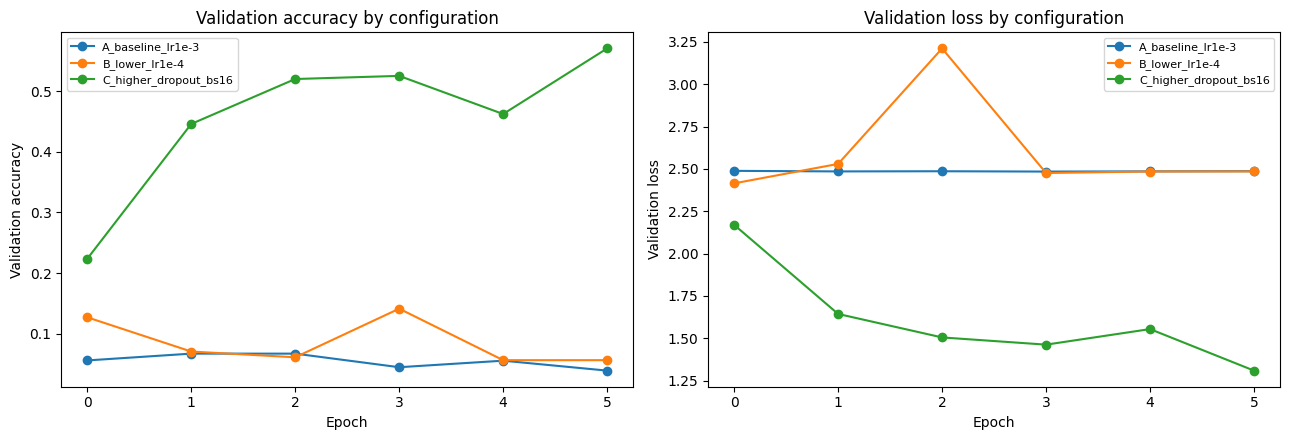

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, hist in hp_histories.items():
    axes[0].plot(hist["val_accuracy"], marker="o", label=name)
    axes[1].plot(hist["val_loss"], marker="o", label=name)
axes[0].set_title("Validation accuracy by configuration")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation accuracy")
axes[0].legend(fontsize=8)
axes[1].set_title("Validation loss by configuration")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation loss")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** the comparison table and curves above show how learning rate and dropout affect
convergence speed and validation accuracy over a short training budget. A learning rate that is too low
(configuration B) is expected to converge more slowly within the same number of epochs, while a higher
dropout rate (configuration C) trades a little training speed for potentially better generalization. The
best-performing configuration by validation accuracy is selected automatically below and used for the
longer final training run.


In [18]:
best_config_name = hp_results_df.iloc[0]["config"]
best_config = hyperparam_configs[best_config_name]
print(f"Best configuration: {best_config_name} -> {best_config}")


Best configuration: C_higher_dropout_bs16 -> {'learning_rate': 0.001, 'dropout_rate': 0.5, 'batch_size': 16}


## 6. Final training run

The best configuration found above is retrained for more epochs, with early stopping on validation loss
and a learning-rate reduction on plateau, so the final model is not just the one that happened to look
best after a short search.


In [19]:
FINAL_EPOCHS = 25

final_train_ds = make_dataset(train_df, training=True, batch_size=best_config["batch_size"])
final_val_ds = make_dataset(val_df, training=False, batch_size=best_config["batch_size"])

tf.keras.utils.set_random_seed(RNG_SEED)
final_model = build_cnn(
    learning_rate=best_config["learning_rate"],
    dropout_rate=best_config["dropout_rate"],
)

callback_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

final_history = final_model.fit(
    final_train_ds,
    validation_data=final_val_ds,
    epochs=FINAL_EPOCHS,
    class_weight=class_weight,
    callbacks=callback_list,
    shuffle=False,  # the tf.data pipeline already shuffles the training set
    verbose=2,
)


Epoch 1/25
678/678 - 22s - loss: 2.1361 - accuracy: 0.2009 - val_loss: 1.9960 - val_accuracy: 0.2577 - lr: 0.0010 - 22s/epoch - 32ms/step
Epoch 2/25
678/678 - 21s - loss: 1.8631 - accuracy: 0.3099 - val_loss: 1.9528 - val_accuracy: 0.3494 - lr: 0.0010 - 21s/epoch - 31ms/step
Epoch 3/25
678/678 - 22s - loss: 1.7120 - accuracy: 0.3973 - val_loss: 1.4995 - val_accuracy: 0.5039 - lr: 0.0010 - 22s/epoch - 32ms/step
Epoch 4/25
678/678 - 21s - loss: 1.5597 - accuracy: 0.4472 - val_loss: 1.3825 - val_accuracy: 0.5349 - lr: 0.0010 - 21s/epoch - 31ms/step
Epoch 5/25
678/678 - 21s - loss: 1.4557 - accuracy: 0.4984 - val_loss: 1.4220 - val_accuracy: 0.5232 - lr: 0.0010 - 21s/epoch - 32ms/step
Epoch 6/25
678/678 - 22s - loss: 1.3744 - accuracy: 0.5398 - val_loss: 1.2278 - val_accuracy: 0.5968 - lr: 0.0010 - 22s/epoch - 32ms/step
Epoch 7/25
678/678 - 20s - loss: 1.3102 - accuracy: 0.5626 - val_loss: 1.2373 - val_accuracy: 0.5783 - lr: 0.0010 - 20s/epoch - 30ms/step
Epoch 8/25
678/678 - 21s - loss: 1

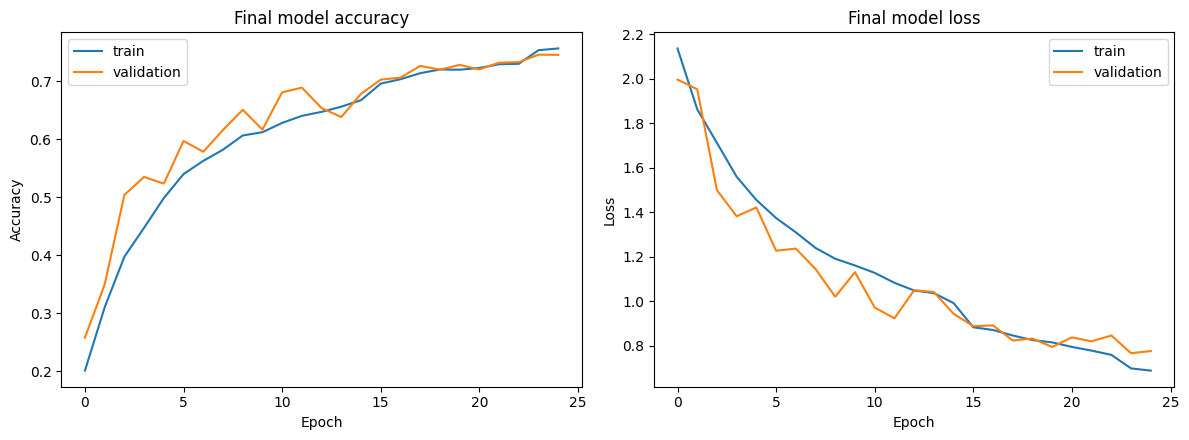

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(final_history.history["accuracy"], label="train")
axes[0].plot(final_history.history["val_accuracy"], label="validation")
axes[0].set_title("Final model accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(final_history.history["loss"], label="train")
axes[1].plot(final_history.history["val_loss"], label="validation")
axes[1].set_title("Final model loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Test set evaluation: confusion matrix, precision, recall, F1-score

The final model is evaluated once on the held-out test set, which it has not seen during hyperparameter
search or final training.


In [21]:
test_ds_ordered = make_dataset(test_df, training=False, batch_size=best_config["batch_size"])
test_loss, test_accuracy = final_model.evaluate(test_ds_ordered, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Test loss: 0.7382
Test accuracy: 0.7626


In [22]:
y_true = []
y_pred = []
for images, labels in test_ds_ordered:
    probs = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(f"Overall accuracy (sklearn check): {accuracy_score(y_true, y_pred):.4f}")


Overall accuracy (sklearn check): 0.7626


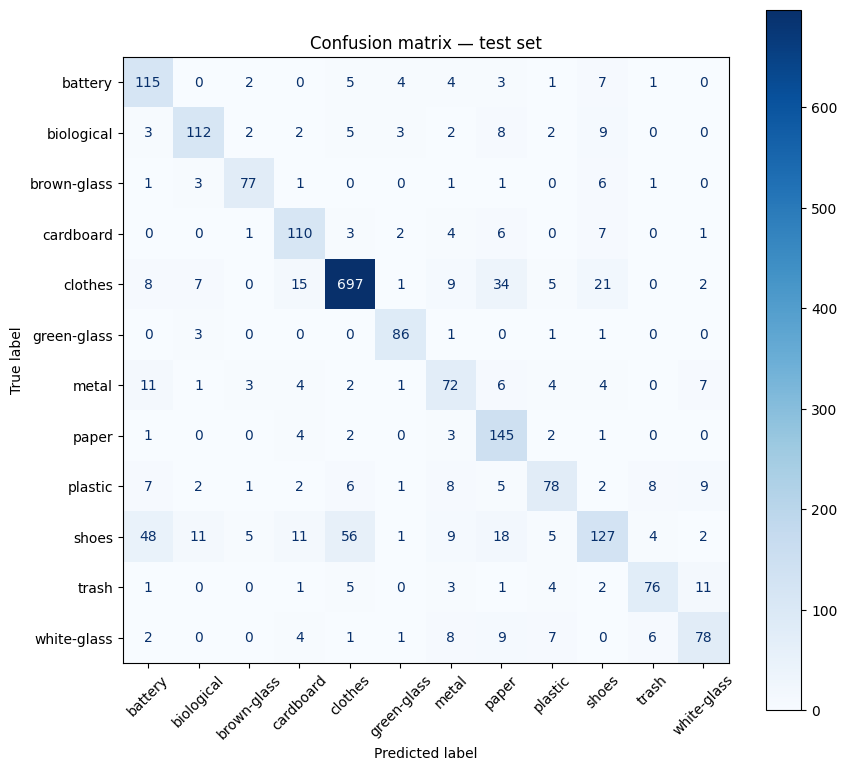

In [23]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.show()


In [24]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(num_classes), zero_division=0
)
per_class_df = pd.DataFrame({
    "class": classes,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support,
}).sort_values("f1_score")
per_class_df


,class,precision,recall,f1_score,support
9,shoes,0.679144,0.427609,0.524793,297
6,metal,0.580645,0.626087,0.602510,115
8,plastic,0.715596,0.604651,0.655462,129
0,battery,0.583756,0.809859,0.678466,142
11,white-glass,0.709091,0.672414,0.690265,116
7,paper,0.614407,0.917722,0.736041,158
10,trash,0.791667,0.730769,0.760000,104
3,cardboard,0.714286,0.820896,0.763889,134
1,biological,0.805755,0.756757,0.780488,148
2,brown-glass,0.846154,0.846154,0.846154,91


In [25]:
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))


              precision    recall  f1-score   support

     battery       0.58      0.81      0.68       142
  biological       0.81      0.76      0.78       148
 brown-glass       0.85      0.85      0.85        91
   cardboard       0.71      0.82      0.76       134
     clothes       0.89      0.87      0.88       799
 green-glass       0.86      0.93      0.90        92
       metal       0.58      0.63      0.60       115
       paper       0.61      0.92      0.74       158
     plastic       0.72      0.60      0.66       129
       shoes       0.68      0.43      0.52       297
       trash       0.79      0.73      0.76       104
 white-glass       0.71      0.67      0.69       116

    accuracy                           0.76      2325
   macro avg       0.73      0.75      0.73      2325
weighted avg       0.77      0.76      0.76      2325



**Reading the results:** the per-class table above is sorted from worst to best F1-score, so the classes
that need the most attention appear first. Based on the Week 2 EDA findings, the classes expected to show
weaker recall are the visually near-identical glass and metal/plastic pairs, and the heterogeneous
`trash` class, while the majority `clothes` class is expected to have strong precision and recall simply
because the model sees far more examples of it. The confusion matrix above should be read with this in
mind: off-diagonal mass concentrated in the glass rows/columns or in metal-vs-plastic confirms the EDA's
second finding, and low recall specifically on `trash` confirms the third.


## 8. Sample predictions

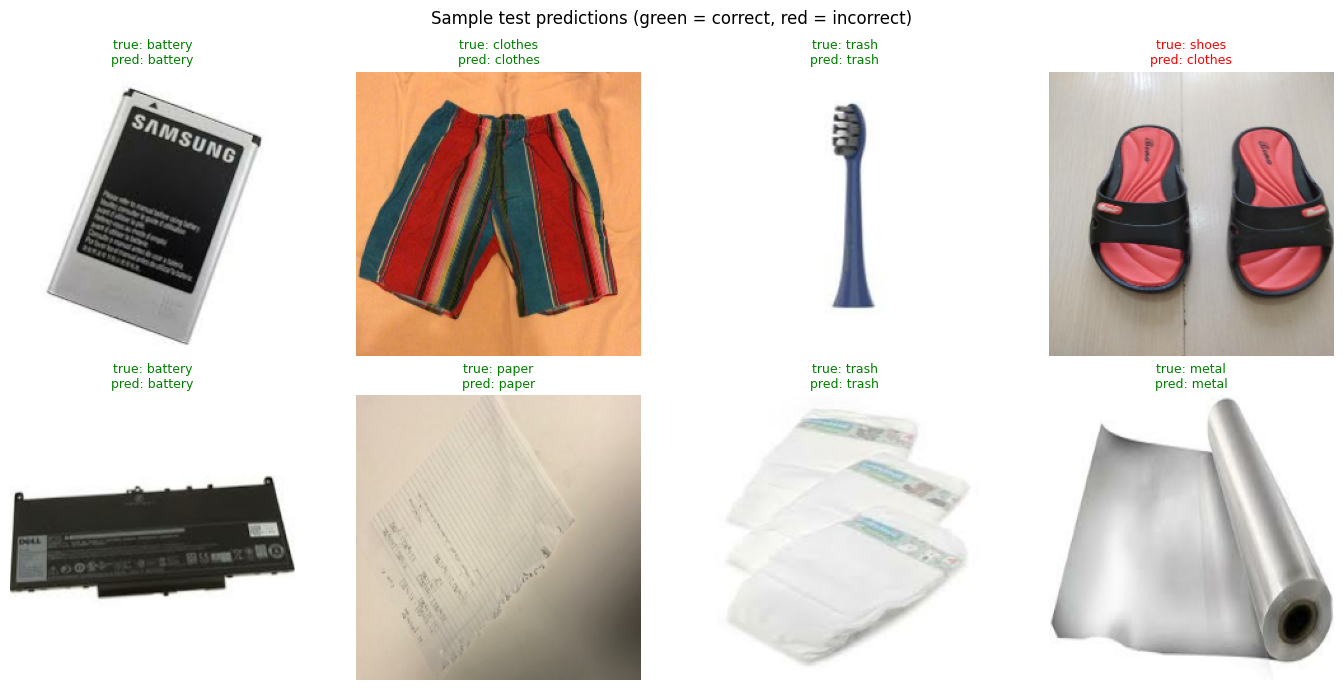

In [26]:
sample_batch_images, sample_batch_labels = next(iter(test_ds_ordered))
sample_probs = final_model.predict(sample_batch_images, verbose=0)
sample_preds = np.argmax(sample_probs, axis=1)

n_show = min(8, len(sample_batch_images))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, true_idx, pred_idx in zip(axes.flatten(), sample_batch_images[:n_show],
                                        sample_batch_labels[:n_show], sample_preds[:n_show]):
    ax.imshow(img.numpy())
    true_label = classes[true_idx.numpy()]
    pred_label = classes[pred_idx]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"true: {true_label}\npred: {pred_label}", fontsize=9, color=color)
    ax.axis("off")
plt.suptitle("Sample test predictions (green = correct, red = incorrect)")
plt.tight_layout()
plt.show()


## 9. Discussion and conclusion

The hyperparameter search in Section 5 shows how learning rate and dropout trade off convergence speed
against generalization within a fixed, short training budget, and the automatic selection in Section 5
carries the better configuration into the longer, callback-controlled final run in Section 6. The test-set
confusion matrix and per-class precision/recall/F1 scores in Section 7 should be interpreted together with
the Week 2 EDA: any confusion concentrated among the glass classes or between metal and plastic, and any
weaker recall on the `trash` class, are expected outcomes of the domain shift and class-imbalance findings
identified during EDA, not surprises. Class-weighted loss was used throughout training specifically to
soften the impact of that imbalance. Next steps for improving the model further would include stronger or
more targeted augmentation for the weakest classes, collecting or oversampling more `trash` and
`brown-glass`/`green-glass` examples, and comparing this from-scratch CNN against a transfer-learning
baseline (e.g. a frozen MobileNetV2 backbone) to see how much headroom remains.
